In [1]:
import cv2
import time
import re
import base64
import json
import io
import os
import traceback
import numpy as np 
import robotic as ry
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv
from openai import OpenAI

from pathlib import Path
from datetime import datetime

from WayTu_RAI.GenerateEnvironment import GenerateEnvironment, PlacementError
import WayTu_RAI.model_utils as mutils

load_dotenv()  # loads OPENAI_API_KEY from .env
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY")) 

ry.params_add({'physx/motorKp': 10000., 
               'physx/motorK  d': 1000., 
               'physx/angularDamping': 10., 
               'physx/defaultFriction': 1000.})

ry.params_add({'botsim/engine': 'physx'})
ry.params_add({'physx/multibody': True})
ry.params_print()

print(ry.__version__)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
0.1.10
physx/motorKp: 10000,
physx/motorK  d: 1000,
physx/angularDamping: 10,
physx/defaultFriction: 1000,
botsim/engine: physx,
physx/multibody

In [2]:
parameters = {
    "num-trials"        : 1,
    "num-tools"         : 3,
    "tool-type"         : 'primitive',
    "task"              : 'minigolf',
    "mode"              : 'test',
    "area-middle"       : { "min": [-0.35 , 0.15, 0.060], "max": [ 0.35 , 0.45, 0.065] },
    "area-negative"     : { "min": [-0.50 , 0.15, 0.050], "max": [ -0.35 , 0.45, 0.060] },
    "area-positive"     : { "min": [0.40 , 0.15, 0.050], "max": [ 0.50 , 0.45, 0.060] },
    "label-list-all"    : ["lifting-platform", "minigolf-platform", "hammering-platform", "hammer", "spatula", "L-ruler", "screwdriver", "ball", "book", "thin-stick", "ring"],
    "cameras"           : ["camera4"],
}

In [3]:
def draw_rgb_and_depth(rgb, depth):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth)
    plt.title("Depth")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def numpy_to_bytes(numpy_image_array, target_size=(336, 336)):
    resized_array = cv2.resize(numpy_image_array, target_size, interpolation=cv2.INTER_AREA)

    if resized_array.dtype != 'uint8':
        resized_array = resized_array.astype('uint8')

    pil_img = Image.fromarray(resized_array)
    byte_stream = io.BytesIO()
    pil_img.save(byte_stream, format='JPEG')
    return byte_stream.getvalue()

In [4]:
def get_prompt_all(task_name, task_desc):
    return f"""You are an expert spatial reasoning model.
You are provided with a 500x500 pixel image view of a robotic workspace.

Camera Roles:
- Front angled view of the robotic workspace, showing the robot, tools, and task objects from an oblique perspective.

TASK: {task_name}
TASK DESCRIPTION: {task_desc}

Look at the camera view and do all of the following together:
1. Select ONE tool from ["Hammer", "L-ruler", "Spatula"] that best fits the task.
2. Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Tool Waypoint.
3. Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Initial Waypoint.
4. Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Goal Waypoint.

Definitions:
- Tool Waypoint: the exact pixel on the selected tool where the robot gripper should physically grasp it.
- Initial Waypoint: the exact pixel representing the tool position immediately before the main task interaction begins.
- Goal Waypoint: the exact pixel representing the tool position after the main task interaction is completed.

Important:
- The Initial Waypoint is a pre-interaction position, not the contact point itself.
- The initial and goal waypoints MUST be different.

Output ONLY a JSON dictionary matching this exact structure. Do not use markdown:
{{
  "selected_tool": "<one of: Hammer, L-ruler, Spatula>",
  "tool_waypoint": {{
    "camera_uv": [0, 0]
  }},
  "initial_waypoint": {{
    "camera_uv": [0, 0]
  }},
  "goal_waypoint": {{
    "camera_uv": [0, 0]
  }}
}}
Begin your JSON response now:"""

In [5]:
# Camera Roles:
# Front angled view of the robotic workspace, showing the robot, tools, and task objects from an oblique perspective.

In [6]:
def get_prompt_detailed(task_name, task_desc):
    return f"""You are an expert spatial reasoning model.
You are provided with a 500x500 pixel image view of a robotic workspace.

  

TASK: {task_name}
TASK DESCRIPTION: {task_desc} 

Because the workspace layout is randomized, you must use the following spatial logic to determine your coordinates:

Scene Identification: Locate the platform, the ball, and the target hole.

    1. Tool Selection Logic: Evaluate the tools in the workspace: ["Hammer", "L-ruler", "Spatula"]. Select the tool that offers the most stable striking surface or effective geometry for pushing a spherical object accurately.
      - **Reasoning**: You must justify your choice by explaining how the tool's shape (e.g., the flat blade of a spatula or the hook of a ruler) allows it to get underneath the stick.

    2. Vector Calculation: Mentally establish a "line of action" that starts behind the ball and passes through the center of the ball directly into the center of the hole.

    3. Tool Waypoint (Grasp): Identify the handle of your chosen tool. The Tool Waypoint should be the pixel representing the optimal grip location on that handle.

    4. Initial Waypoint (Setup): Identify the striking surface of the tool. Position this surface on the "line of action," a short distance away from the ball on the side furthest from the hole. It should be "aimed" at the hole but not yet touching the ball.

    5. Goal Waypoint (Execution): Define the end of the pushing motion. This point must be further along the "line of action," moving through the ball's original position toward the hole to ensure a successful delivery.

Look at the camera view and do all of the following together:
    - Select ONE tool from ["hammer", "L-ruler", "spatula"] that best fits the task based on the logic above.
    - Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Tool Waypoint.
    - Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Initial Waypoint.
    - Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Goal Waypoint.

Definitions:
    Tool Waypoint: The pixel where the robot gripper should physically grasp the tool handle.
    Initial Waypoint: The position of the tool's business end (head/blade) just before it makes contact with the ball.
    Goal Waypoint: The position of the tool's business end after the pushing motion is complete.

Important:
    The Initial Waypoint must be "behind" the ball relative to the hole's location.
    The Initial and Goal waypoints MUST be different to represent a vector of motion.

Output ONLY a JSON dictionary matching this exact structure. Do not use markdown:
{{
  "selected_tool": "<hammer, L-ruler, or spatula>",
  "selection_reasoning": "<1-2 sentences explaining why this tool fits the mechanical requirement of sliding under and lifting>",
  "tool_waypoint": {{
    "camera_uv": [u, v]
  }},
  "initial_waypoint": {{
    "camera_uv": [u, v]
  }},
  "goal_waypoint": {{
    "camera_uv": [u, v]
  }}
}}

Begin your JSON response now:"""

In [7]:
def ask_openai_with_image(prompt, image_bytes, model="gpt-5.4"):
    image_b64 = base64.b64encode(image_bytes).decode("utf-8")

    response = client.responses.create(
        model=model,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{image_b64}"
                    }
                ]
            }
        ]
    )

    return response.output_text.strip()

In [8]:
def extract_json(text):
    text = text.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise ValueError(f"Could not parse JSON from:\n{text}")

In [9]:
def visualize_predicted_waypoints(camera_images, predicted_data, trial_idx, save_dir, vlm_size=500):
    rgb = camera_images[0]
    H, W = rgb.shape[:2]

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(f"Camera - Trial {trial_idx}")
    plt.axis("off")

    waypoint_styles = {
        'tool_waypoint': {'color': 'red', 'marker': 'X', 'label': 'Tool'},
        'initial_waypoint': {'color': 'orange', 'marker': 'o', 'label': 'Initial'},
        'goal_waypoint': {'color': 'lime', 'marker': 's', 'label': 'Goal'}
    }

    scale_u = W / vlm_size
    scale_v = H / vlm_size

    for wp_key, style in waypoint_styles.items():
        if wp_key in predicted_data and "camera_uv" in predicted_data[wp_key]:
            u_vlm, v_vlm = predicted_data[wp_key]["camera_uv"]
            u_img = u_vlm * scale_u
            v_img = v_vlm * scale_v

            plt.scatter(
                u_img, v_img,
                s=120,
                marker=style["marker"],
                label=style["label"],
                edgecolors="black",
                linewidths=1.5
            )

    plt.legend()
    plt.tight_layout()

    save_path = save_dir / f"trial_{trial_idx:03d}_waypoints.png"
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)

In [10]:
def get_point_from_pcl(predicted_data, pcls, key):
    u, v = predicted_data[key]["camera_uv"]
    print(pcls[0].shape)
    point = pcls[0][v, u]   # row = v, col = u
    print("point: ", point)
    return point

def camera_point_to_world(point_cam, cam_frame):
    R = cam_frame.getRotationMatrix()
    t = cam_frame.getPosition()

    point_world = R @ point_cam + t
    return point_world

def get_world_point(predicted_data, pcls, cam_frame, key):
    point_cam = get_point_from_pcl(predicted_data, pcls, key)
    point_world = camera_point_to_world(point_cam, cam_frame)
    return point_cam, point_world

In [11]:
def find_selected_tool_by_pc(environment, tool_point_world):
    points_xyz = environment.point_clouds_labels[:, :3] 
    labels = environment.point_clouds_labels[:, 3]

    # Mapping to update the string for your logs/final data
    tool_labels_map = {3: "hammer", 4: "spatula", 5: "L-ruler"}

    min_distance = float('inf')
    best_tool_label = None

    # 2. Iterate through all valid tool labels to find the closest one to the predicted waypoint
    for current_label in [3, 4, 5]:
        # Isolate the point cloud for the current tool
        current_tool_mask = np.isin(labels, current_label)
    
        
        tool_points = points_xyz[current_tool_mask]
        
        # 3. Calculate Euclidean distance from the predicted waypoint to all points on this tool
        distances = np.linalg.norm(tool_points - tool_point_world, axis=1)
    
        # Find the shortest distance to this specific tool
        closest_point_dist = np.min(distances)
    
        # 4. Update if this tool is the closest one found so far
        if closest_point_dist < min_distance:
            min_distance = closest_point_dist
            best_tool_label = current_label

    # 5. Override the VLM's text selection with the spatially grounded selection
    tool_label = best_tool_label
    selected_tool_name = tool_labels_map.get(best_tool_label, "unknown")
    
    return selected_tool_name

Saving to: test_runs/2026-04-07_16-45-51
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0], 'shape': 'ssBox', 'size': [2.5, 2.5, 0.1, 0.02], 'color': [0.3, 0.3, 0.3], 'contact': 1, 'logical': {}, 'friction': 0.1, 'X': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0]}
table threshold:  0.655
camera height:  [0.   0.9  1.22]
{'min': array([-0.40455279,  0.08914189,  0.61263187]), 'max': array([-0.26455279,  0.38914189,  0.71263187]), 'center': array([-0.33455279,  0.23914189,  0.66263187]), 'quaternion': array([0.93460913, 0.        , 0.        , 0.35567651]), 'rotation_z': 41.66982382978756}
AAAAAAAAAAAAAAAAAAAAA:  (250000,)
(1277, 3)
(1277, 3)
[0, 0, 255]
obj name: spatula, label: 4
{'min': array([0.10042264, 0.12568629, 0.617353  ]), 'max': array([0.24042264, 0.44568629, 0.717353  ]), 'center': array([0.17042264, 0.28568629, 0.667353  ]), 'quaternion': array([ 0.7375743 ,  0.        ,  0.        , -0.67526599]), 'rotation_z': -84.94961848036864}
AAAAAAAAAAAAAAAAAAAAA:  (250000,

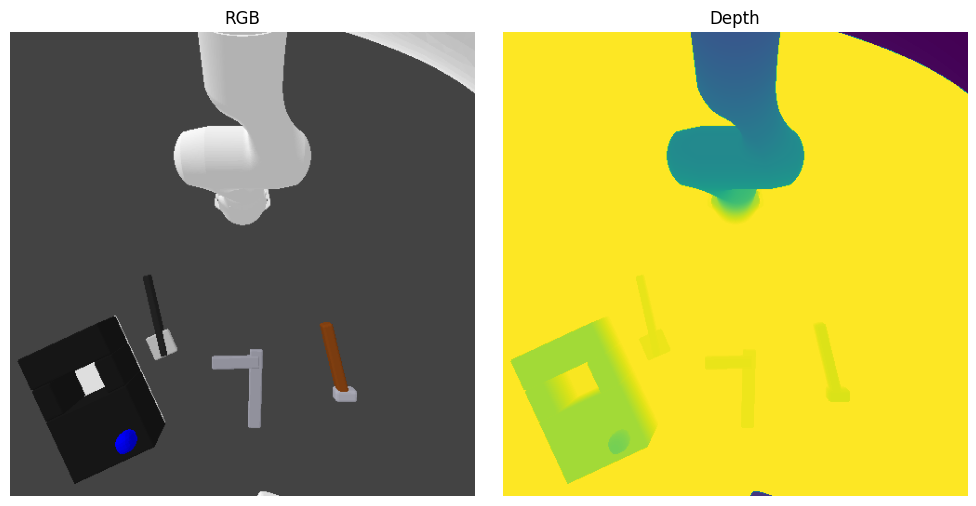


Trial 0 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula provides the broadest, flattest pushing surface, making it the most stable option for a controlled, accurate push on a spherical ball. Its flat blade can be aligned behind the ball and driven straight along the line toward the hole more reliably than the hammer or L-ruler.",
  "tool_waypoint": {
    "camera_uv": [
      373,
      335
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      101,
      451
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      71,
      391
    ]
  }
}


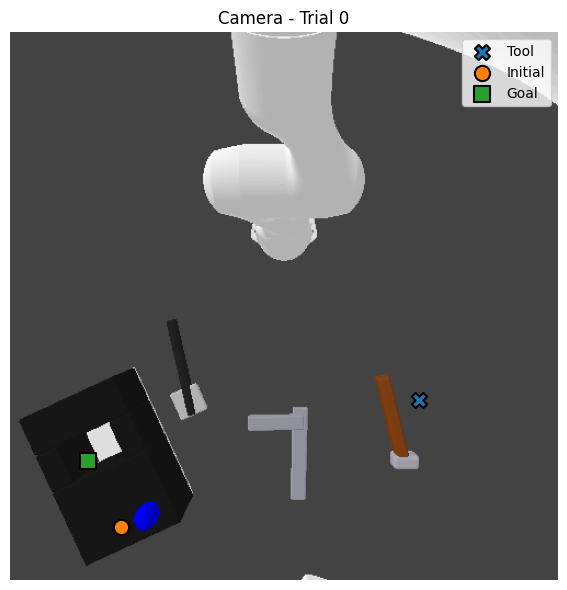

Saved: test_runs/2026-04-07_16-45-51/trial_000_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.38376012 0.26520011 0.78000027]
(500, 500, 3)
point:  [-0.40382993  0.54476386  0.67756701]
(500, 500, 3)
point:  [-0.53136057  0.41855776  0.74212372]
tool point: [0.38376012 0.26520011 0.78000027]
init point: [-0.40382993  0.54476386  0.67756701]
goal point: [-0.53136057  0.41855776  0.74212372]
camera position: [0.   0.   1.43]
camera rotation matrix:
 [[-1.0000000e+00  0.0000000e+00  1.2246468e-16]
 [ 0.0000000e+00  1.0000000e+00  0.0000000e+00]
 [-1.2246468e-16  0.0000000e+00 -1.0000000e+00]]
ball world position: [0.32584147 0.49930276 0.77743286]
(500, 500, 3)
point:  [0.38376012 0.26520011 0.78000027]
(500, 500, 3)
point:  [-0.40382993  0.54476386  0.67756701]
(500, 500, 3)
point:  [-0.53136057  0.41855776  0.74212372]
tool point camera: [0.38376012 0.26520011 0.78000027]
tool point world: [-0.38376012  0.26520011  0.64999973]
initial point camera: [-0.40382993  0.5

In [12]:
run_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_dir = Path("test_runs") / run_time
save_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", save_dir)
trial = 0

evaluation_stats = {
    "vlm_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "pc_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "total_mismatches": 0,
    "mismatch_log": []  # To store the exact details of what went wrong
}

while trial < parameters["num-trials"]:
    try:
        environment = GenerateEnvironment(parameters)
        environment.generate_environment()
        environment.C.delFrame("pcl")
        environment.C.view()

        rgb_images, depth_images, pcls = mutils.get_rgb_images(environment.C, parameters["cameras"], environment.C.getFrame("camera4"))
        # f = environment.C.addFrame('pcl', 'world')
        # f.setPointCloud(points= pcls[0], colors = [0,0,255])
        print("RGB shape:", rgb_images[0].shape)
        print("Depth shape:", depth_images[0].  shape )
        print("Point cloud shape:", pcls[0      ].shape)
        draw_rgb_and_depth(rgb_images[0], depth_images[0])
        environment.C.view()

        image_bytes = numpy_to_bytes(rgb_images[0], (500, 500))

        if parameters["task"] == "minigolf":
            task_name = "Precision Minigolf: Tool-Assisted Ball Striking"
            # task_description = "Use the tool to push the ball into the hole on the platform."
            task_description = "The objective is to use a tool to perform a controlled push of a blue spherical ball into a white target hole located on a raised black rectangular platform."
        elif parameters["task"] == "lifting":
            task_description = "Use the tool to lift the stick upward from the target platform."
            task_name = ""

        else:
            raise Exception("Unknown task")
        

        print(f"\nTrial {trial} | Calling OpenAI...")


        print("Asking for tool selection and all waypoints together...")

        raw_resp = ask_openai_with_image(
            get_prompt_detailed(parameters["task"], task_description),
            image_bytes
        )

        final_predicted_data = extract_json(raw_resp)

        print("\nFinal predicted data:")
        print(json.dumps(final_predicted_data, indent=2))

        visualize_predicted_waypoints(
            rgb_images,
            final_predicted_data,
            trial,
            save_dir,
            vlm_size=500
            )
        print(f"pcl size main: {pcls[0].shape}")
        tool_point = get_point_from_pcl(final_predicted_data, pcls, "tool_waypoint")
        init_point = get_point_from_pcl(final_predicted_data, pcls, "initial_waypoint")
        goal_point = get_point_from_pcl(final_predicted_data, pcls, "goal_waypoint")

        print("tool point:", tool_point)
        print("init point:", init_point)
        print("goal point:", goal_point)

        cam_frame = environment.C.getFrame("camera4")
        print("camera position:", cam_frame.getPosition())
        print("camera rotation matrix:\n", cam_frame.getRotationMatrix())

        ball_frame = environment.C.getFrame("minigolf-obj")
        print("ball world position:", ball_frame.getPosition())

        tool_point_cam, tool_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "tool_waypoint")
        init_point_cam, init_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "initial_waypoint")
        goal_point_cam, goal_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "goal_waypoint")

       
        print("tool point camera:", tool_point_cam)
        print("tool point world:", tool_point_world)

        print("initial point camera:", init_point_cam)
        print("initial point world:", init_point_world)

        print("goal point camera:", goal_point_cam)
        print("goal point world:", goal_point_world)

        print("selected tool:", final_predicted_data["selected_tool"])


        
        # print(f"Selected tool center: {environment.C.getFrame(best_tool + '-head').getPosition()}")
        # print(f"Selected tool center: {tool_point_world}")
        # 
        if final_predicted_data["selected_tool"] == "hammer":
            tool_label = 3
        elif final_predicted_data["selected_tool"] == "spatula":
            tool_label = 4
        elif final_predicted_data["selected_tool"] == "L-ruler":
            tool_label = 5
        
        tool_mask = np.isin(environment.point_clouds_labels[:,3], tool_label)
        tool_pc = environment.point_clouds_labels[tool_mask]
        f = environment.C.addFrame('tool-pcl', 'world')
        f.setPointCloud(points= tool_pc[:,:3], colors = [0,0,255])
        environment.C.view()

        grasp_position = mutils.post_posititon(tool_pc[:,:3], tool_point_world)
        selected_tool_pc = find_selected_tool_by_pc(environment, tool_point_world)
        print("selected tool by point cloud: ", selected_tool_pc)
        selected_tool_base = selected_tool_pc + "-base"
        print("selected tool base: ", selected_tool_base)
        grasp_position[2] = environment.C.getFrame(selected_tool_pc+'-base').getPosition()[2] - 0.01
        init_point_world[2] = environment.C.getFrame("minigolf-obj").getPosition()[2]
        goal_point_world[2] = environment.C.getFrame("minigolf-obj").getPosition()[2]

        environment.C.addFrame("tool-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(grasp_position)

        environment.C.addFrame("initial-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(init_point_world)

        environment.C.addFrame("goal-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(goal_point_world)
        
        environment.C.view()

        best_tool = final_predicted_data["selected_tool"]
        selected_part = mutils.find_grasping_part(
                environment.C,
                selected_tool_pc,
                tool_point_world
            )
        other_tools = [item for item in environment.tool_objs if item != selected_tool_pc]
        mutils.reparent_tool(environment.C, best_tool, selected_part, other_tools)

        

        environment.C.getFrame("tool-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        environment.C.getFrame("initial-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        environment.C.getFrame("goal-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        # environment.C.getFrame("initial-waypoint").setQuaternion(mutils.rotate_quat_yaw_angle(environment.C.getFrame("minigolf-platform").getQuaternion(), 90))

        mutils.ManipulationWithKOMO_minigolf(environment.C, best_tool, environment.env)


        vlm_tool = final_predicted_data["selected_tool"]
        pc_tool = selected_tool_pc

        if vlm_tool in evaluation_stats["vlm_selected"]:
            evaluation_stats["vlm_selected"][vlm_tool] += 1
        else:
            print("Unknown VLM tool:", vlm_tool)

        if pc_tool in evaluation_stats["pc_selected"]:
            evaluation_stats["pc_selected"][pc_tool] += 1

        # 4. Check for and log any mismatches
        if vlm_tool != pc_tool:
            evaluation_stats["total_mismatches"] += 1
            evaluation_stats["mismatch_log"].append({
                "vlm_text_prediction": vlm_tool,
                "pc_spatial_correction": pc_tool
            })


        trial += 1

    except PlacementError as e:
        print("PlacementError:", e)
        print("Retrying trial...")
    except Exception as e:
        print("Exception occurred:")
        traceback.print_exc()
        break
    
print("\n" + "="*50)
print(" VLM vs. Spatial Point Cloud Evaluation Results")
print("="*50)

# Print the overall counts
print("\n--- Total Selections ---")
print("VLM Text Predictions:")
for tool, count in evaluation_stats["vlm_selected"].items():
    print(f"  - {tool}: {count}")

print("\nSpatial Point Cloud Corrections:")
for tool, count in evaluation_stats["pc_selected"].items():
    print(f"  - {tool}: {count}")

# Print the mismatch details
print("\n--- Mismatch Summary ---")
print(f"Total Mismatches: {evaluation_stats['total_mismatches']}")

if evaluation_stats["total_mismatches"] > 0:
    print("\nDetailed Mismatch Log:")
    for idx, mismatch in enumerate(evaluation_stats["mismatch_log"], 1):
        print(f"  {idx}. VLM selected '{mismatch['vlm_text_prediction']}', "
              f"but the spatial waypoint was closest to '{mismatch['pc_spatial_correction']}'.")
else:
    print("\nNo mismatches found! The VLM text and spatial waypoints aligned perfectly.")

print("="*50 + "\n")

Saving to: test_runs/2026-04-07_16-46-28
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0], 'shape': 'ssBox', 'size': [2.5, 2.5, 0.1, 0.02], 'color': [0.3, 0.3, 0.3], 'contact': 1, 'logical': {}, 'friction': 0.1, 'X': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0]}
table threshold:  0.655
camera height:  [0.   0.9  1.22]
{'min': array([-0.24282277,  0.1360511 ,  0.6134131 ]), 'max': array([-0.10282277,  0.4360511 ,  0.7134131 ]), 'center': array([-0.17282277,  0.2860511 ,  0.6634131 ]), 'quaternion': array([0.84297044, 0.        , 0.        , 0.53795989]), 'rotation_z': 65.08973426642484}
AAAAAAAAAAAAAAAAAAAAA:  (250000,)
(1205, 3)
(1205, 3)
[0, 0, 255]
obj name: spatula, label: 4
{'min': array([-0.31068119,  0.10415075,  0.61910074]), 'max': array([-0.17068119,  0.42415075,  0.71910074]), 'center': array([-0.24068119,  0.26415075,  0.66910074]), 'quaternion': array([ 0.96129198,  0.        ,  0.        , -0.27553172]), 'rotation_z': -31.987407305759902}
{'min': array([-0.2961

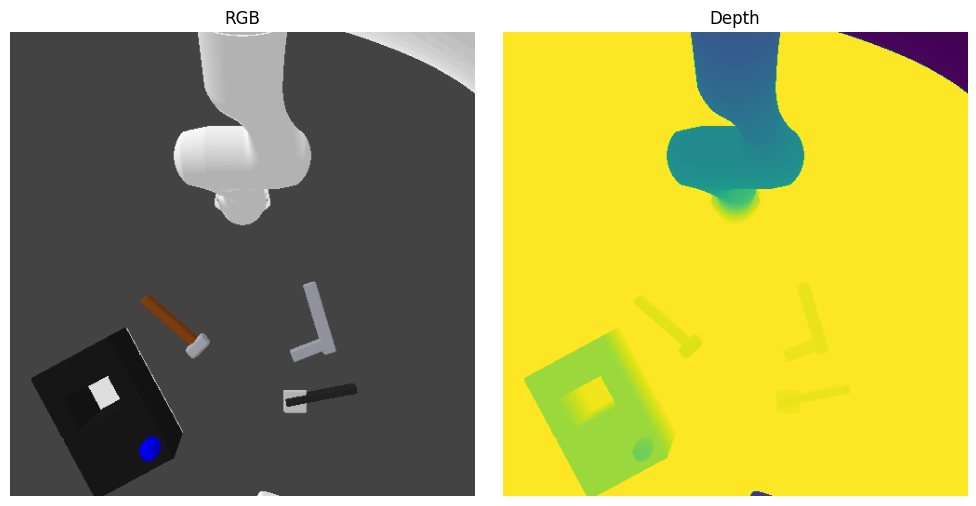


Trial 0 | Calling OpenAI...
Asking for tool selection and all waypoints together...


In [ ]:
run_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_dir = Path("test_runs") / run_time
save_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", save_dir)
trial = 0

evaluation_stats = {
    "vlm_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "pc_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "total_mismatches": 0,
    "mismatch_log": []  # To store the exact details of what went wrong
}

while trial < parameters["num-trials"]:
    try:
        environment = GenerateEnvironment(parameters)
        environment.generate_environment()
        environment.C.delFrame("pcl")
        environment.C.view()

        rgb_images, depth_images, pcls = mutils.get_rgb_images(environment.C, parameters["cameras"], environment.C.getFrame("camera4"))
        # f = environment.C.addFrame('pcl', 'world')
        # f.setPointCloud(points= pcls[0], colors = [0,0,255])
        print("RGB shape:", rgb_images[0].shape)
        print("Depth shape:", depth_images[0].  shape )
        print("Point cloud shape:", pcls[0      ].shape)
        draw_rgb_and_depth(rgb_images[0], depth_images[0])
        environment.C.view()

        image_bytes = numpy_to_bytes(rgb_images[0], (500, 500))

        if parameters["task"] == "minigolf":
            task_name = "Precision Minigolf: Tool-Assisted Ball Striking"
            # task_description = "Use the tool to push the ball into the hole on the platform."
            task_description = "The objective is to use a tool to perform a controlled push of a blue spherical ball into a white target hole located on a raised black rectangular platform."
        elif parameters["task"] == "lifting":
            task_description = "Use the tool to lift the stick upward from the target platform."
            task_name = ""

        else:
            raise Exception("Unknown task")
        

        print(f"\nTrial {trial} | Calling OpenAI...")


        print("Asking for tool selection and all waypoints together...")

        raw_resp = ask_openai_with_image(
            get_prompt_detailed(parameters["task"], task_description),
            image_bytes
        )

        final_predicted_data = extract_json(raw_resp)

        print("\nFinal predicted data:")
        print(json.dumps(final_predicted_data, indent=2))

        visualize_predicted_waypoints(
            rgb_images,
            final_predicted_data,
            trial,
            save_dir,
            vlm_size=500
            )
        print(f"pcl size main: {pcls[0].shape}")
        tool_point = get_point_from_pcl(final_predicted_data, pcls, "tool_waypoint")
        init_point = get_point_from_pcl(final_predicted_data, pcls, "initial_waypoint")
        goal_point = get_point_from_pcl(final_predicted_data, pcls, "goal_waypoint")

        print("tool point:", tool_point)
        print("init point:", init_point)
        print("goal point:", goal_point)

        cam_frame = environment.C.getFrame("camera4")
        print("camera position:", cam_frame.getPosition())
        print("camera rotation matrix:\n", cam_frame.getRotationMatrix())

        ball_frame = environment.C.getFrame("minigolf-obj")
        print("ball world position:", ball_frame.getPosition())

        tool_point_cam, tool_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "tool_waypoint")
        init_point_cam, init_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "initial_waypoint")
        goal_point_cam, goal_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "goal_waypoint")

       
        print("tool point camera:", tool_point_cam)
        print("tool point world:", tool_point_world)

        print("initial point camera:", init_point_cam)
        print("initial point world:", init_point_world)

        print("goal point camera:", goal_point_cam)
        print("goal point world:", goal_point_world)

        print("selected tool:", final_predicted_data["selected_tool"])


        
        # print(f"Selected tool center: {environment.C.getFrame(best_tool + '-head').getPosition()}")
        # print(f"Selected tool center: {tool_point_world}")
        # 
        if final_predicted_data["selected_tool"] == "hammer":
            tool_label = 3
        elif final_predicted_data["selected_tool"] == "spatula":
            tool_label = 4
        elif final_predicted_data["selected_tool"] == "L-ruler":
            tool_label = 5
        
        tool_mask = np.isin(environment.point_clouds_labels[:,3], tool_label)
        tool_pc = environment.point_clouds_labels[tool_mask]
        f = environment.C.addFrame('tool-pcl', 'world')
        f.setPointCloud(points= tool_pc[:,:3], colors = [0,0,255])
        environment.C.view()

        grasp_position = mutils.post_posititon(tool_pc[:,:3], tool_point_world)
        selected_tool_pc = find_selected_tool_by_pc(environment, tool_point_world)
        print("selected tool by point cloud: ", selected_tool_pc)
        selected_tool_base = selected_tool_pc + "-base"
        print("selected tool base: ", selected_tool_base)
        grasp_position[2] = environment.C.getFrame(selected_tool_pc+'-base').getPosition()[2] - 0.01
        init_point_world[2] = environment.C.getFrame("minigolf-obj").getPosition()[2]
        goal_point_world[2] = environment.C.getFrame("minigolf-obj").getPosition()[2]

        environment.C.addFrame("tool-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(grasp_position)

        environment.C.addFrame("initial-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(init_point_world)

        environment.C.addFrame("goal-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(goal_point_world)
        
        environment.C.view()

        best_tool = final_predicted_data["selected_tool"]
        selected_part = mutils.find_grasping_part(
                environment.C,
                selected_tool_pc,
                tool_point_world
            )
        other_tools = [item for item in environment.tool_objs if item != selected_tool_pc]
        mutils.reparent_tool(environment.C, best_tool, selected_part, other_tools)

        

        environment.C.getFrame("tool-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        environment.C.getFrame("initial-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        environment.C.getFrame("goal-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        # environment.C.getFrame("initial-waypoint").setQuaternion(mutils.rotate_quat_yaw_angle(environment.C.getFrame("minigolf-platform").getQuaternion(), 90))

        mutils.ManipulationWithKOMO_minigolf(environment.C, best_tool, environment.env)


        vlm_tool = final_predicted_data["selected_tool"]
        pc_tool = selected_tool_pc

        if vlm_tool in evaluation_stats["vlm_selected"]:
            evaluation_stats["vlm_selected"][vlm_tool] += 1
        else:
            print("Unknown VLM tool:", vlm_tool)

        if pc_tool in evaluation_stats["pc_selected"]:
            evaluation_stats["pc_selected"][pc_tool] += 1

        # 4. Check for and log any mismatches
        if vlm_tool != pc_tool:
            evaluation_stats["total_mismatches"] += 1
            evaluation_stats["mismatch_log"].append({
                "vlm_text_prediction": vlm_tool,
                "pc_spatial_correction": pc_tool
            })


        trial += 1

    except PlacementError as e:
        print("PlacementError:", e)
        print("Retrying trial...")
    except Exception as e:
        print("Exception occurred:")
        traceback.print_exc()
        break
    
print("\n" + "="*50)
print(" VLM vs. Spatial Point Cloud Evaluation Results")
print("="*50)

# Print the overall counts
print("\n--- Total Selections ---")
print("VLM Text Predictions:")
for tool, count in evaluation_stats["vlm_selected"].items():
    print(f"  - {tool}: {count}")

print("\nSpatial Point Cloud Corrections:")
for tool, count in evaluation_stats["pc_selected"].items():
    print(f"  - {tool}: {count}")

# Print the mismatch details
print("\n--- Mismatch Summary ---")
print(f"Total Mismatches: {evaluation_stats['total_mismatches']}")

if evaluation_stats["total_mismatches"] > 0:
    print("\nDetailed Mismatch Log:")
    for idx, mismatch in enumerate(evaluation_stats["mismatch_log"], 1):
        print(f"  {idx}. VLM selected '{mismatch['vlm_text_prediction']}', "
              f"but the spatial waypoint was closest to '{mismatch['pc_spatial_correction']}'.")
else:
    print("\nNo mismatches found! The VLM text and spatial waypoints aligned perfectly.")

print("="*50 + "\n")

In [ ]:
environment.C.view()

0